<a href="https://colab.research.google.com/github/Nikhil5566/EDA-Repo/blob/main/Earthquake_Alert_Prediction_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Earthquake Alert Prediction Dataset

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

In [4]:
# Installing Kaggle API
!pip install -q kaggle

# Uploading kaggle.json
from google.colab import files
files.upload()

# Moving kaggle.json to ~/.kaggle/
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Downloading the dataset using Kaggle API
!kaggle datasets download -d ahmeduzaki/earthquake-alert-prediction-dataset

# Unziping the downloaded file
!unzip earthquake-alert-prediction-dataset.zip

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/ahmeduzaki/earthquake-alert-prediction-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
  0% 0.00/8.45k [00:00<?, ?B/s]
100% 8.45k/8.45k [00:00<00:00, 25.5MB/s]
Archive:  earthquake-alert-prediction-dataset.zip
  inflating: earthquake_alert_balanced_dataset.csv  


In [5]:
df = pd.read_csv('earthquake_alert_balanced_dataset.csv')
df.head(11)

,magnitude,depth,cdi,mmi,sig,alert
0,7.0,14.0,8.0,7.0,0.0,green
1,6.9,25.0,4.0,4.0,-33.0,green
2,7.0,579.0,3.0,3.0,-13.0,green
3,7.3,37.0,5.0,5.0,65.0,green
4,6.6,624.0,0.0,2.0,-98.0,green
5,7.0,660.0,4.0,3.0,-13.0,green
6,6.8,630.0,1.0,3.0,-57.0,green
7,6.7,20.0,7.0,6.0,29.0,green
8,6.8,20.0,8.0,7.0,-101.0,yellow
9,7.6,26.0,9.0,8.0,7.0,yellow


In [7]:
df.tail(11)

,magnitude,depth,cdi,mmi,sig,alert
1289,6.90,13.0,9.0,8.0,116.0,yellow
1290,7.64,13.0,9.0,6.0,19.0,yellow
1291,8.33,21.0,9.0,7.0,1.0,yellow
1292,7.25,42.0,7.0,6.0,-115.0,yellow
1293,7.91,23.0,8.0,8.0,40.0,yellow
1294,7.65,23.0,7.0,8.0,32.0,yellow
1295,6.87,11.0,9.0,7.0,13.0,yellow
1296,7.85,93.0,8.0,6.0,-51.0,yellow
1297,7.48,142.0,7.0,6.0,120.0,yellow
1298,7.04,51.0,7.0,6.0,-115.0,yellow


In [8]:
df.shape

(1300, 6)

In [9]:
df.columns

Index(['magnitude', 'depth', 'cdi', 'mmi', 'sig', 'alert'], dtype='object')

In [10]:
df.dtypes

,0
magnitude,float64
depth,float64
cdi,float64
mmi,float64
sig,float64
alert,object


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   magnitude  1300 non-null   float64
 1   depth      1300 non-null   float64
 2   cdi        1300 non-null   float64
 3   mmi        1300 non-null   float64
 4   sig        1300 non-null   float64
 5   alert      1300 non-null   object 
dtypes: float64(5), object(1)
memory usage: 61.1+ KB


In [12]:
df.describe(include = 'all')

,magnitude,depth,cdi,mmi,sig,alert
count,1300.000000,1300.000000,1300.000000,1300.000000,1300.000000,1300
unique,NaN,NaN,NaN,NaN,NaN,4
top,NaN,NaN,NaN,NaN,NaN,green
freq,NaN,NaN,NaN,NaN,NaN,325
mean,7.061008,50.321538,6.976154,6.939231,-9.749231,NaN
std,0.423738,104.348286,2.244875,1.354774,62.245214,NaN
min,6.500000,2.000000,0.000000,1.000000,-128.000000,NaN
25%,6.700000,12.000000,6.000000,6.000000,-54.000000,NaN
50%,7.000000,19.000000,8.000000,7.000000,-7.000000,NaN
75%,7.300000,38.000000,8.000000,8.000000,31.000000,NaN


# Univariate Analysis

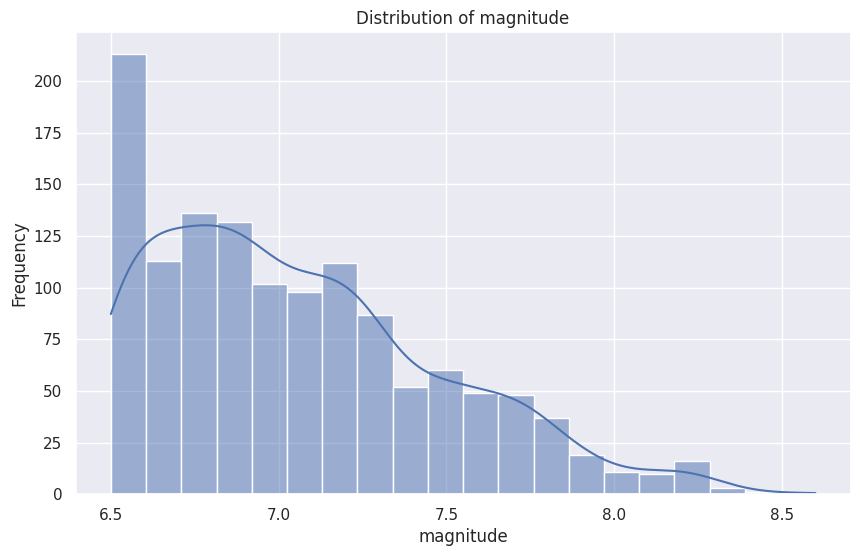

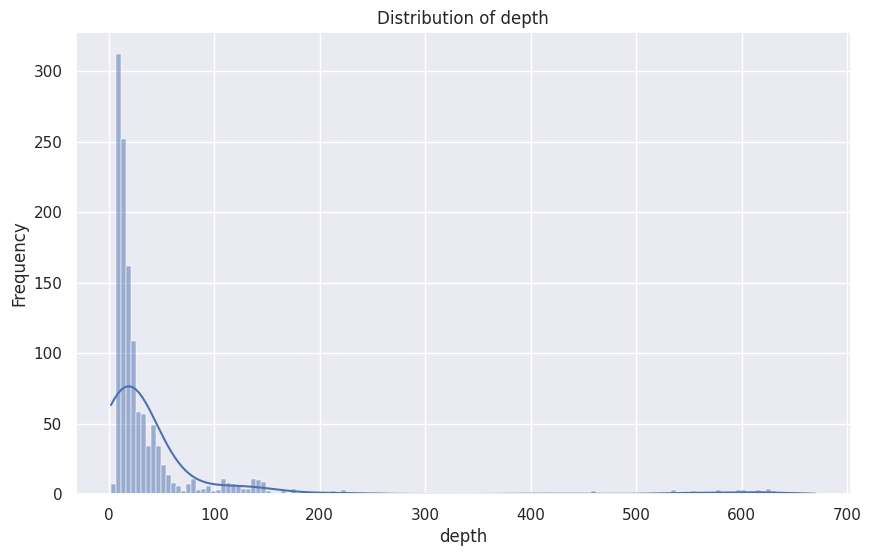

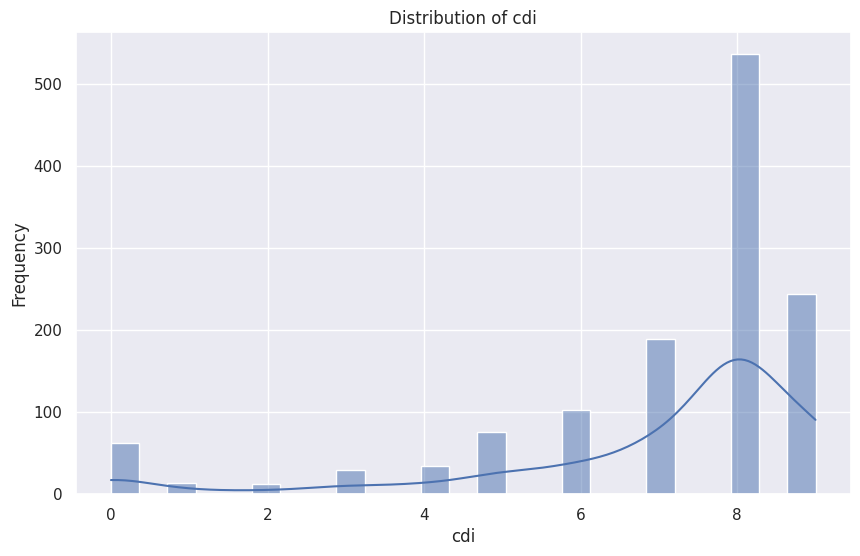

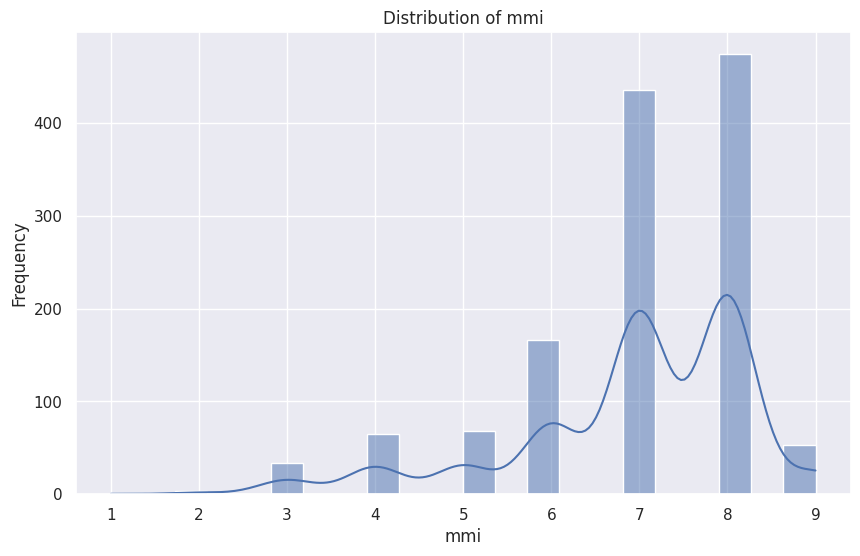

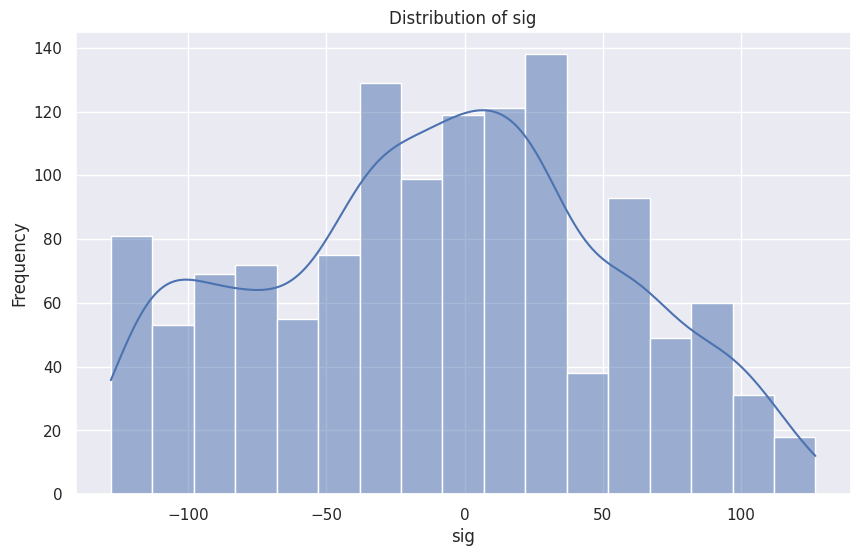

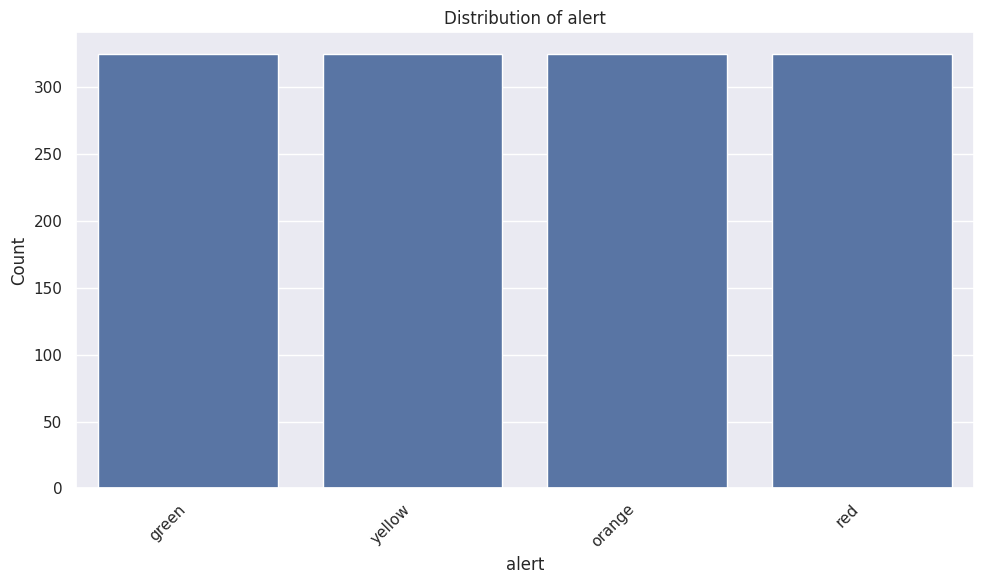

Value counts for alert:
alert
green     325
yellow    325
orange    325
red       325
Name: count, dtype: int64



In [13]:
# Get a list of numerical columns
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through numerical columns and create histograms
for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.histplot(data=df, x=col, kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

# Get a list of categorical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# Iterate through categorical columns and create countplots
for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df, x=col)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# We can also use value_counts for a quick look at categorical data distribution
for col in categorical_cols:
    print(f"Value counts for {col}:\n{df[col].value_counts()}\n")

# Bivariate Analysis

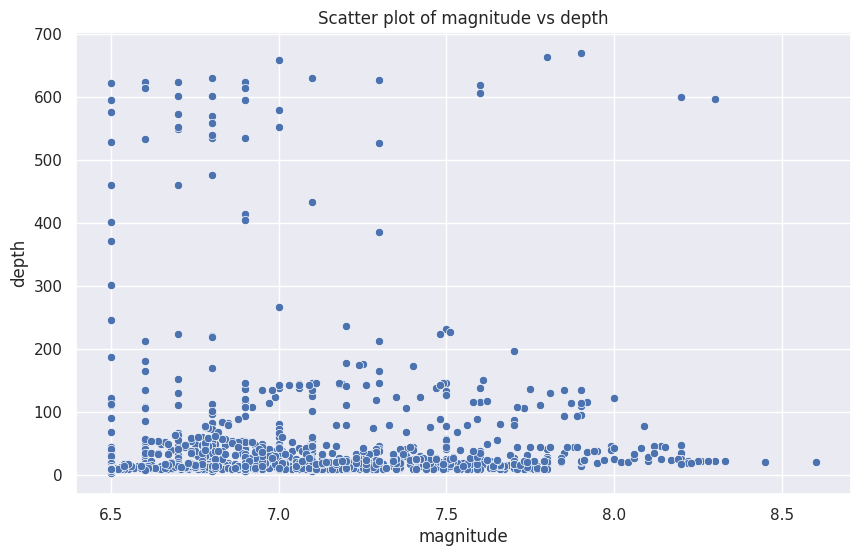

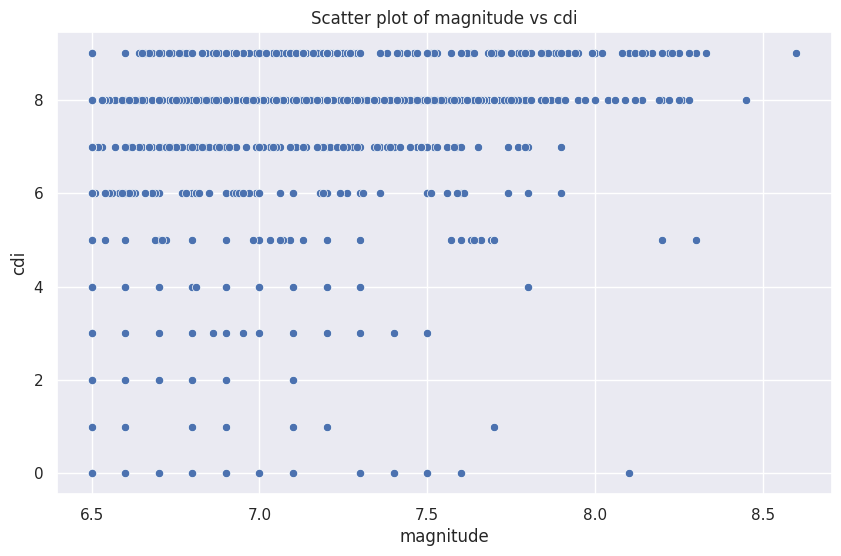

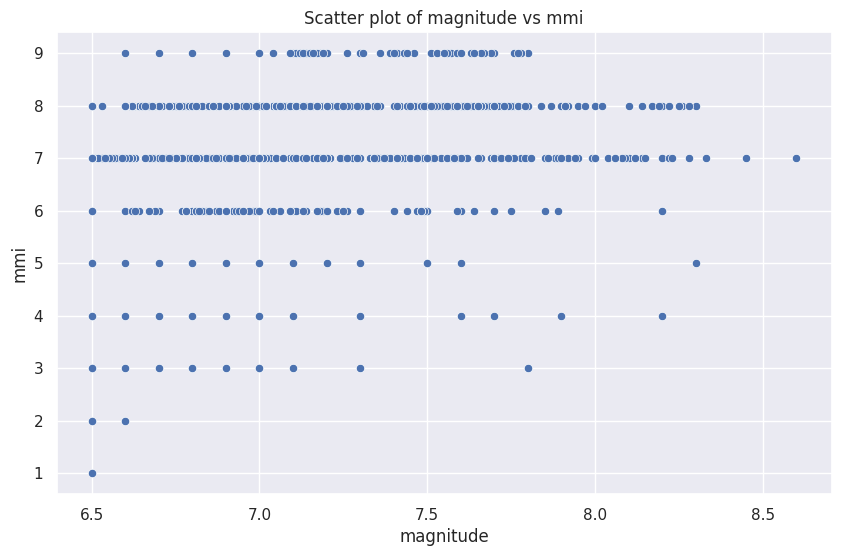

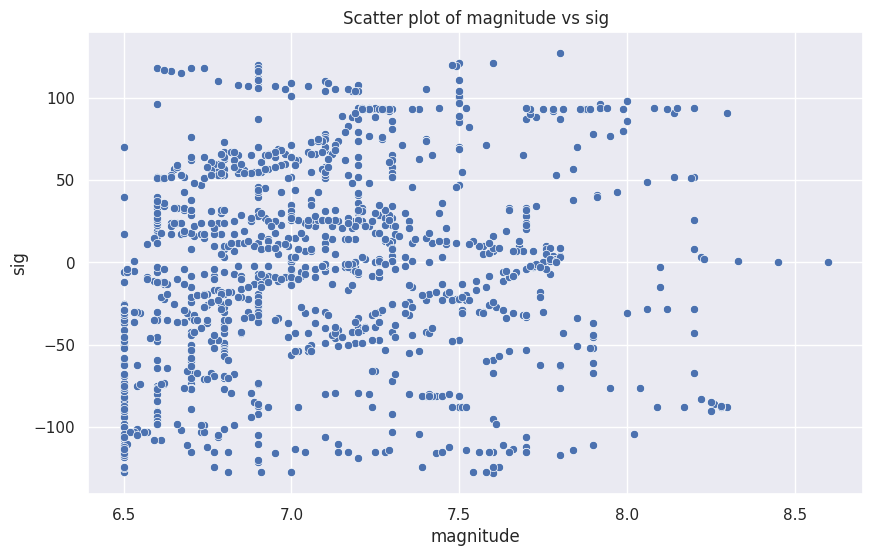

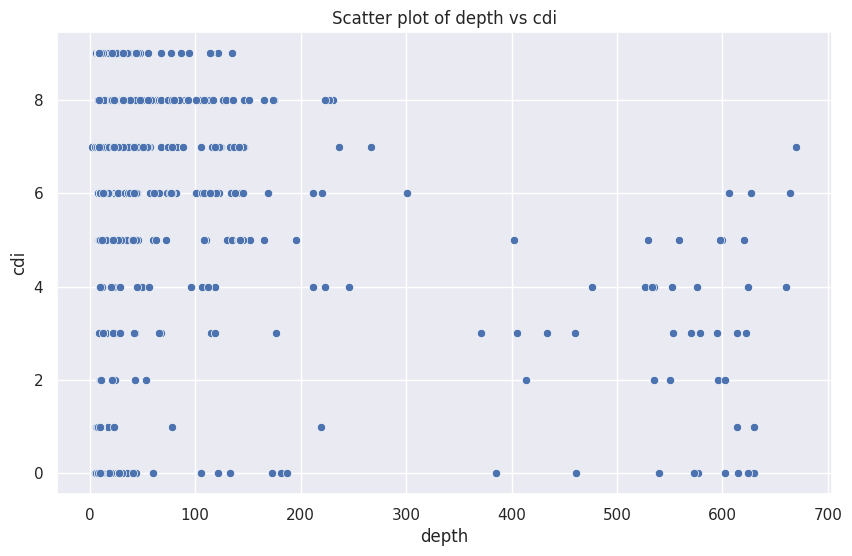

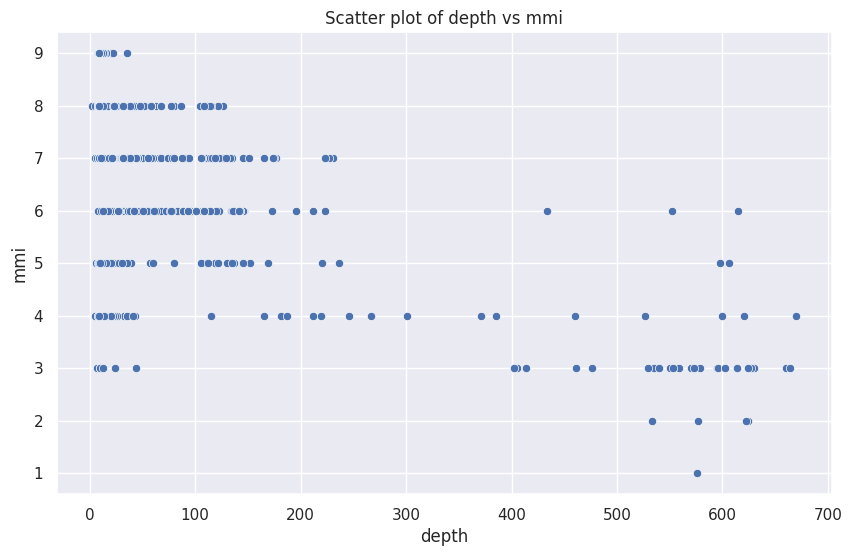

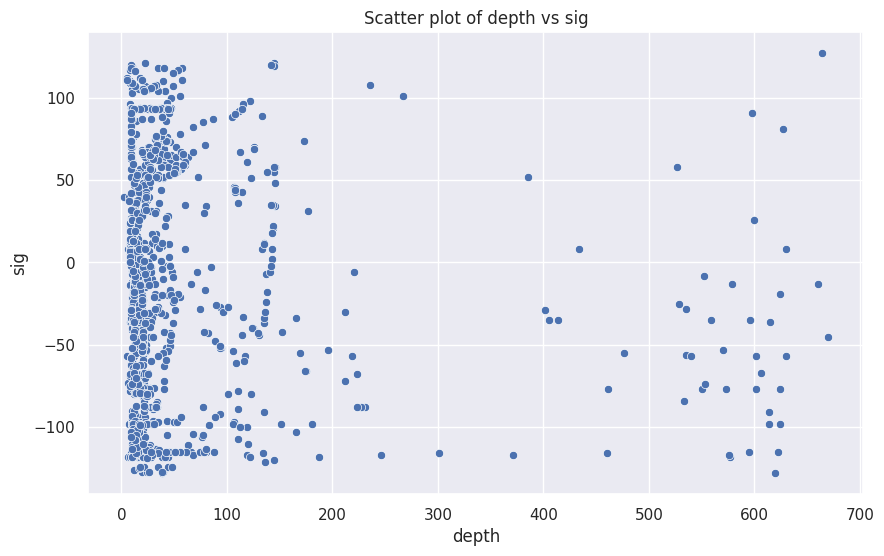

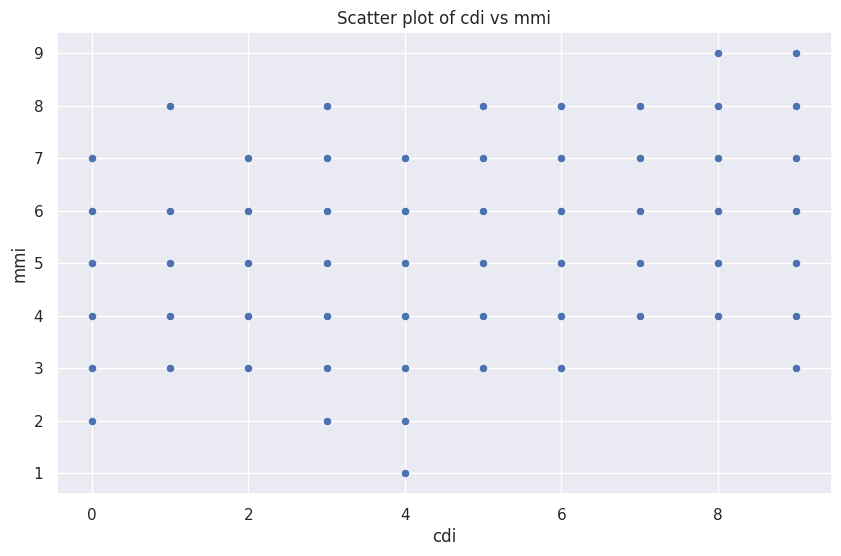

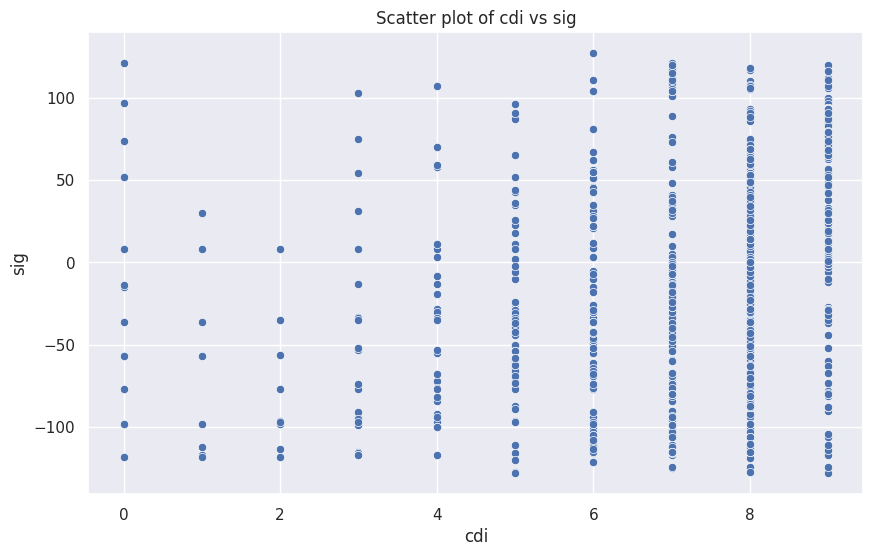

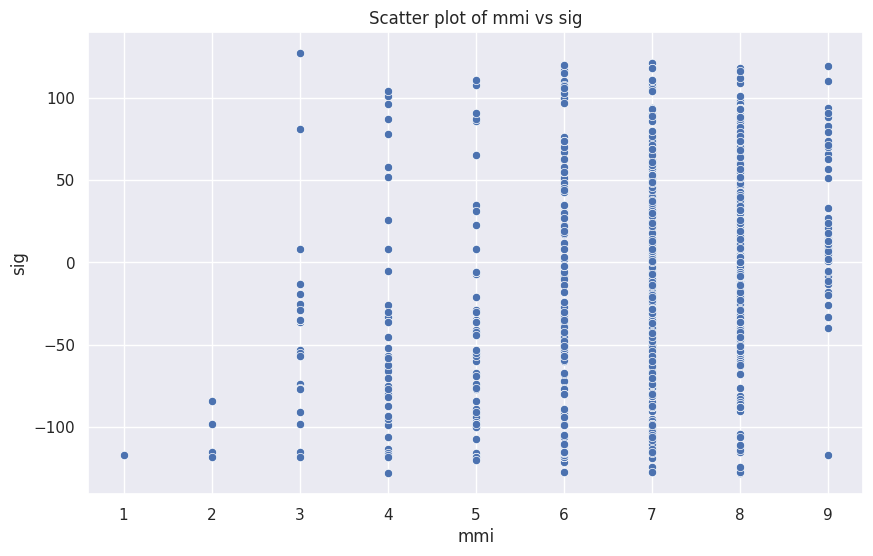

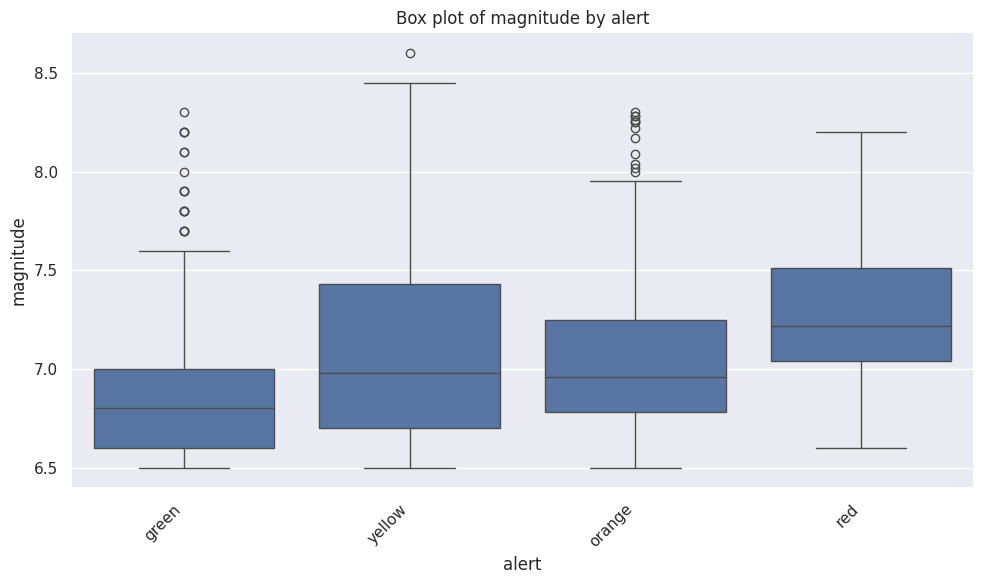

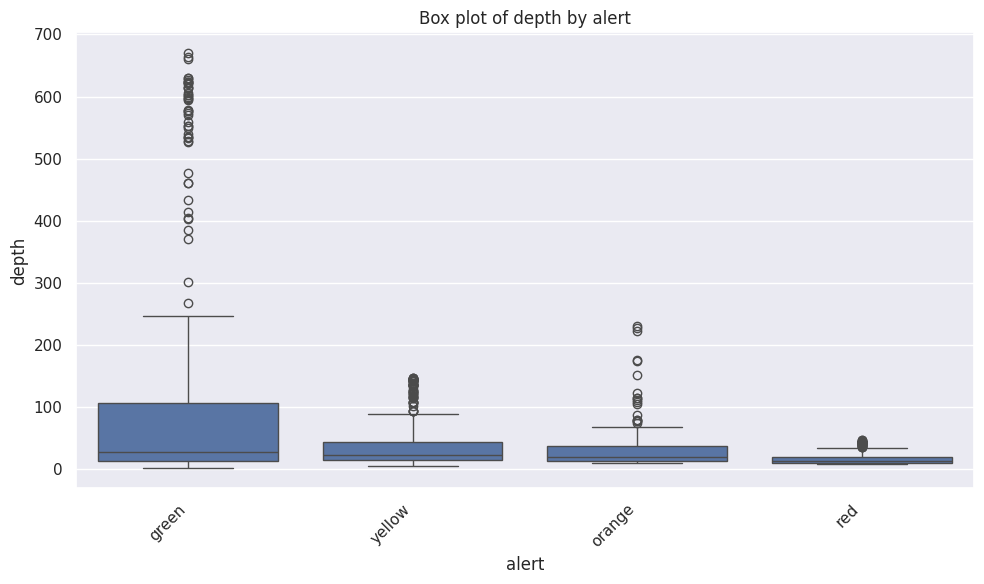

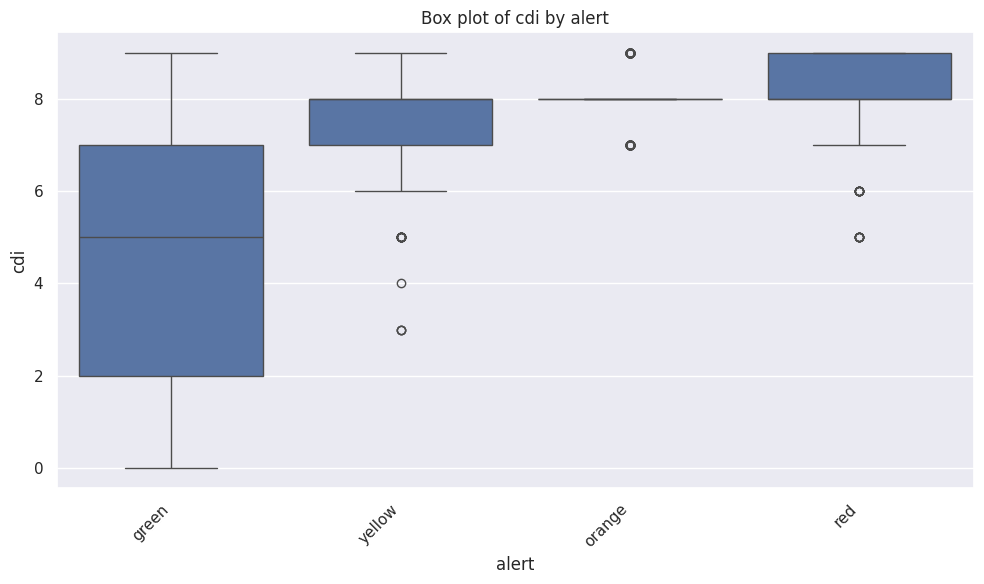

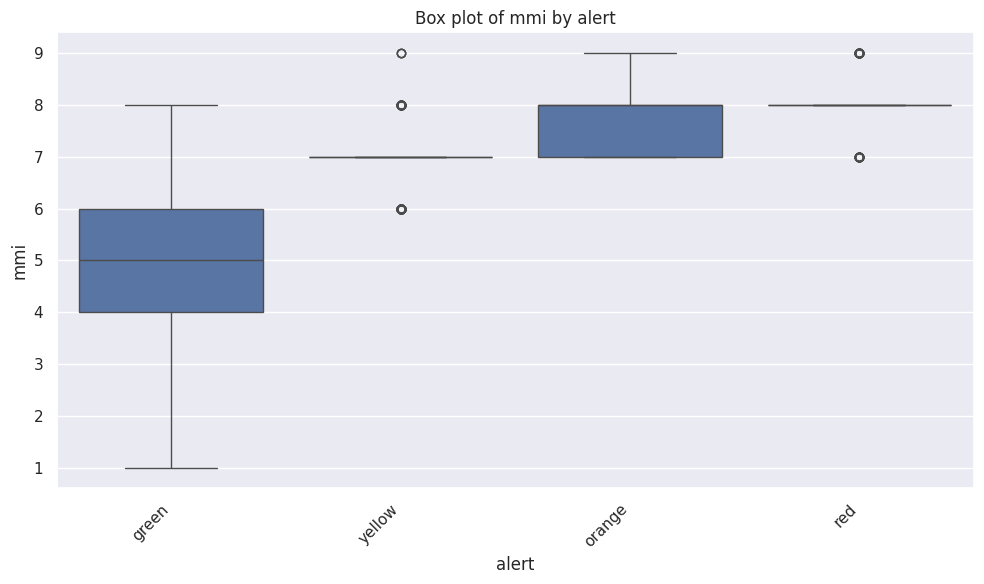

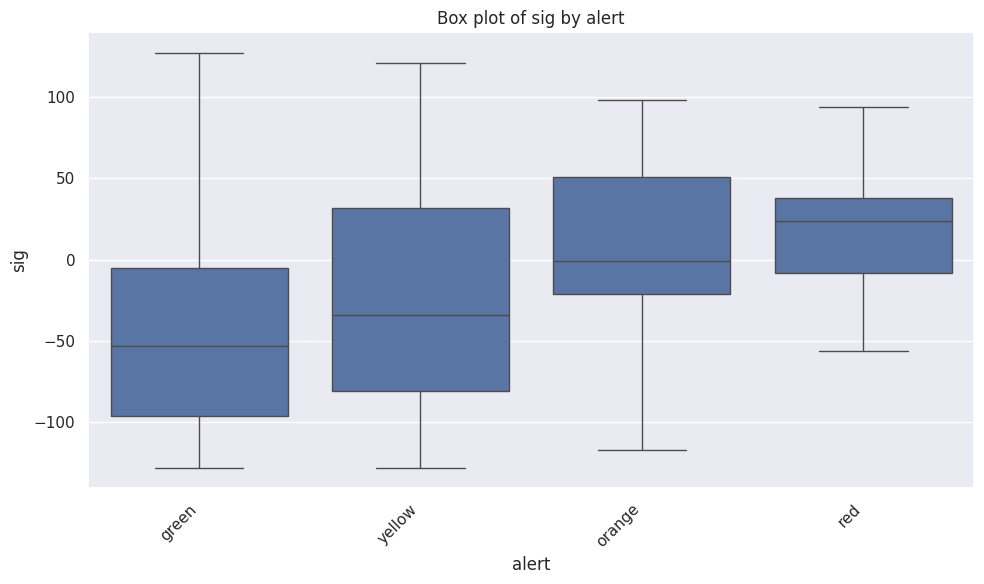

In [14]:
# Numerical-Numerical relationships (Scatter plots)
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through pairs of numerical columns and create scatter plots
for i in range(len(numerical_cols)):
    for j in range(i + 1, len(numerical_cols)):
        col1 = numerical_cols[i]
        col2 = numerical_cols[j]
        plt.figure(figsize=(10, 6))
        sns.scatterplot(data=df, x=col1, y=col2)
        plt.title(f'Scatter plot of {col1} vs {col2}')
        plt.xlabel(col1)
        plt.ylabel(col2)
        plt.show()

# Categorical-Numerical relationships (Box plots)
categorical_cols = df.select_dtypes(include='object').columns.tolist()
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Iterate through categorical and numerical columns and create box plots
for cat_col in categorical_cols:
    for num_col in numerical_cols:
        plt.figure(figsize=(10, 6))
        sns.boxplot(data=df, x=cat_col, y=num_col)
        plt.title(f'Box plot of {num_col} by {cat_col}')
        plt.xlabel(cat_col)
        plt.ylabel(num_col)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

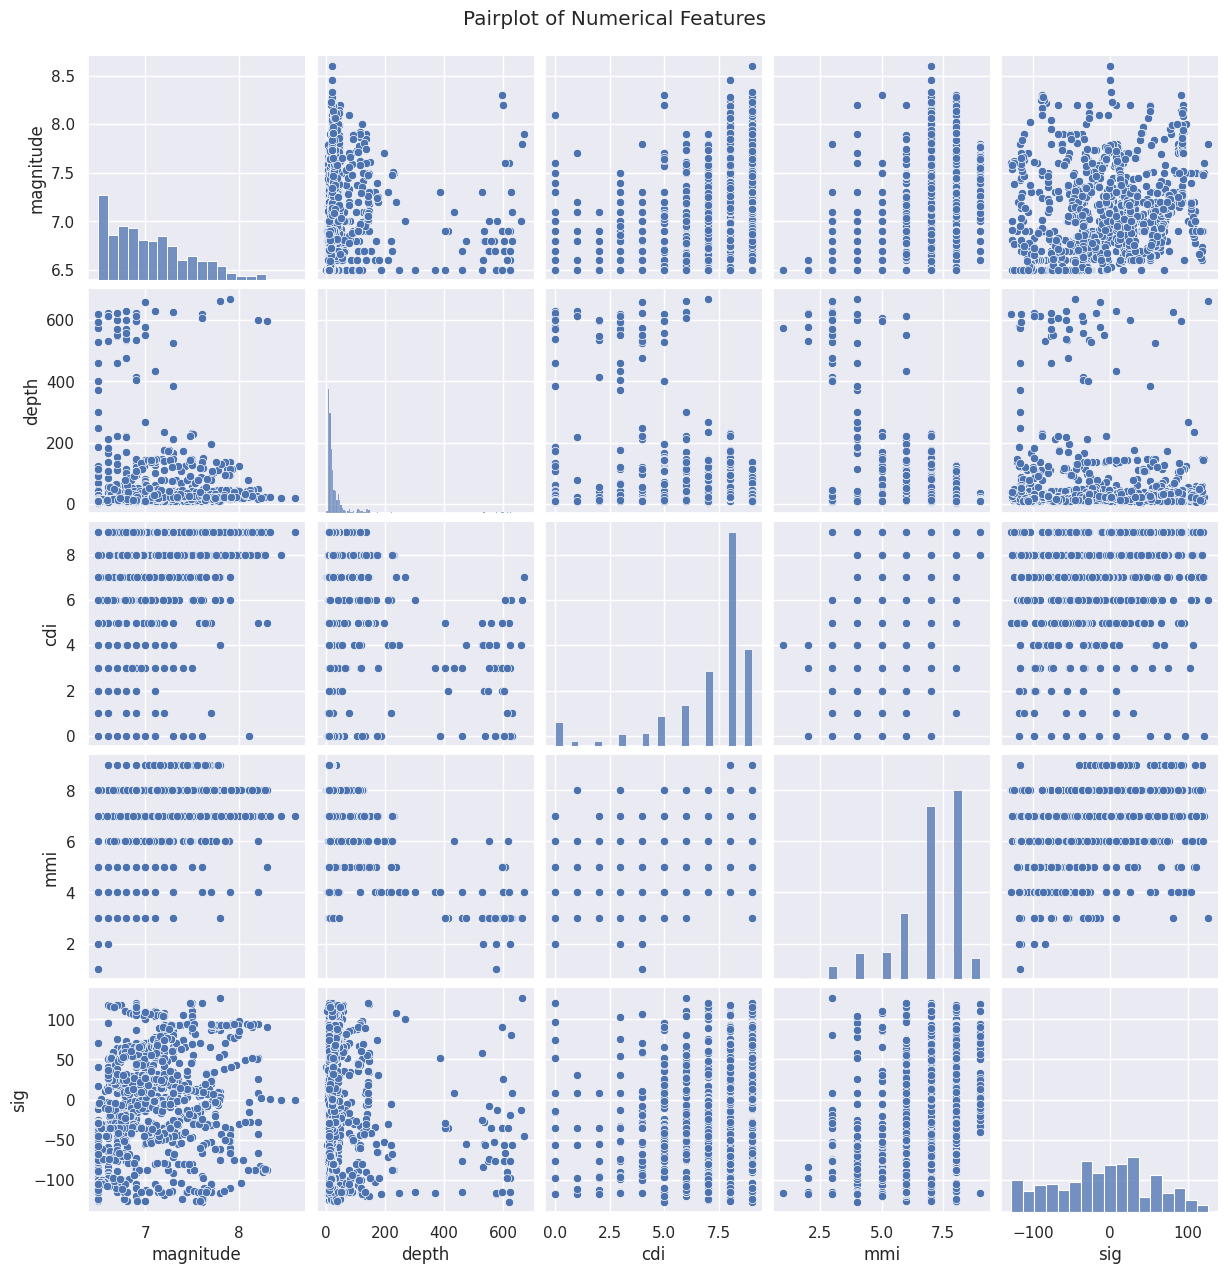

In [15]:
sns.pairplot(df.select_dtypes(include=np.number))
plt.suptitle('Pairplot of Numerical Features', y=1.02)
plt.show()

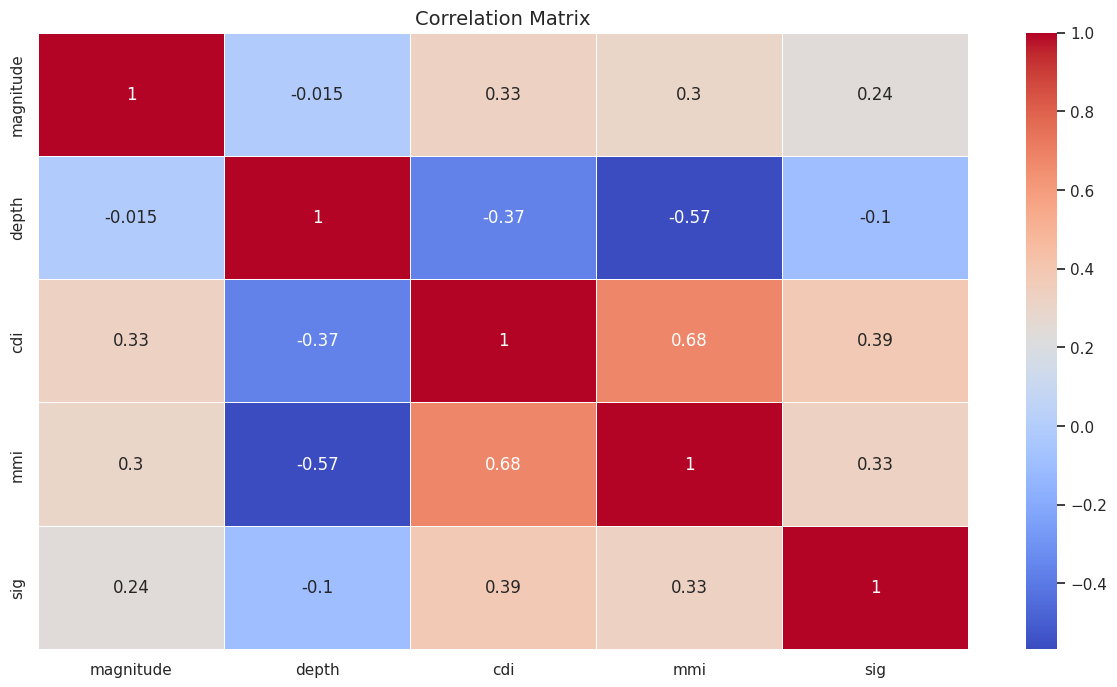

In [16]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.corr(numeric_only = True), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=14)
plt.show()

# Thank you